In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('/home/tec/Projects/machine_learning/dataset/credit_card_frauds.csv')

In [2]:
# 1. Converter as colunas de texto (string) para o formato datetime do Pandas
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# 2. Calcular a idade em anos no exato momento em que a fraude/transação ocorreu
df['idade'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# 3. Remover a coluna original 'dob', pois ela cumpriu seu propósito
df = df.drop(columns=['dob'])

# 4. Remove a coluna temporal que já usamos para calcular a idade
df = df.drop(columns=['trans_date_trans_time'], errors='ignore')

In [3]:
# 1. Definir a função matemática para calcular a distância esférica
def calcular_haversine(lat1, lon1, lat2, lon2):
    # Converte graus para radianos
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Diferença das coordenadas
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Fórmula de Haversine
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Raio da Terra em km
    r = 6371.0 
    return c * r

# 2. Aplicar a função criando a nova feature contínua
df['distancia_km'] = calcular_haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

# 3. Eliminar as coordenadas absolutas (ruído espacial)
df = df.drop(columns=['lat', 'long', 'merch_lat', 'merch_long'])

In [4]:
# Exclui o identificador único da transação
df = df.drop(columns=['trans_num'])

In [5]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
# 1. Instanciar o RobustScaler
scaler = RobustScaler()

# 2. Ajustar (fit) e transformar (transform) a coluna 'amt'
# O Pandas exige colchetes duplos [['amt']] porque o Scikit-Learn espera um array 2D
df['amt'] = scaler.fit_transform(df[['amt']])

In [6]:
# Verifica se as colunas velhas sumiram, se 'idade' e 'distancia_km' apareceram
# e se todos os tipos de dados (Dtype) restantes são numéricos (int64 ou float64)
df.info()

# Verifica se a coluna 'amt' agora está padronizada (valores orbitando perto de 0, com extremos preservados)
display(df[['amt', 'idade', 'distancia_km']].describe())

<class 'pandas.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   merchant      339607 non-null  str    
 1   category      339607 non-null  str    
 2   amt           339607 non-null  float64
 3   city          339607 non-null  str    
 4   state         339607 non-null  str    
 5   city_pop      339607 non-null  int64  
 6   job           339607 non-null  str    
 7   is_fraud      339607 non-null  int64  
 8   idade         339607 non-null  int64  
 9   distancia_km  339607 non-null  float64
dtypes: float64(2), int64(3), str(5)
memory usage: 25.9 MB


,amt,idade,distancia_km
count,339607.000000,339607.000000,339607.000000
mean,0.327024,47.329808,75.577644
std,2.192207,17.033876,29.054393
min,-0.616407,17.000000,0.205072
25%,-0.499797,34.000000,54.734118
50%,0.000000,45.000000,77.612616
75%,0.500203,58.000000,97.947789
max,391.897492,93.000000,152.117173


In [7]:
# 1. Separação entre Features e Label
# Regressão Logística só utiliza valores numéricos
df_numerico = df.select_dtypes(include=[np.number])

features = df_numerico.drop(columns=['is_fraud'])
label = df_numerico['is_fraud']

# 2. Divisão em Treino e Teste (80% Treino, 20% Teste)
# O parâmetro 'stratify' é crucial em cibersegurança: ele garante que a mesma 
# proporção minúscula de fraudes exista tanto no treino quanto no teste.
features_train, features_test, label_train, label_test = train_test_split(features, label, test_size=0.2, random_state=42, stratify=label)

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Simula um sistema burro que aprova TODAS as transações (prevê sempre 0 - Legítima)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(features_train, label_train)
label_pred_dummy = dummy.predict(features_test)

print("--- RESULTADOS DO BASELINE (REGRA CEGA) ---")
print(f"Acurácia:  {accuracy_score(label_test, label_pred_dummy):.4f}")
print(f"Recall:    {recall_score(label_test, label_pred_dummy):.4f}")
print("-" * 40)

--- RESULTADOS DO BASELINE (REGRA CEGA) ---
Acurácia:  0.9948
Recall:    0.0000
----------------------------------------


In [9]:
from sklearn.linear_model import LogisticRegression

# Instancia o modelo linear sem nenhum tratamento de peso ou balanceamento
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(features_train, label_train)
label_pred_log = log_reg.predict(features_test)

print("\n--- RESULTADOS DA REGRESSÃO LOGÍSTICA (SEM BALANCEAMENTO) ---")
print(f"Acurácia:  {accuracy_score(label_test, label_pred_log):.4f}")
print(f"Precisão:  {precision_score(label_test, label_pred_log, zero_division=0):.4f}")
print(f"Recall:    {recall_score(label_test, label_pred_log):.4f}")
print(f"F1-Score:  {f1_score(label_test, label_pred_log):.4f}")

print("\n--- MATRIZ DE CONFUSÃO ---")
cm = confusion_matrix(label_test, label_pred_log)
print(f"Verdadeiros Negativos (TN): {cm[0][0]}")
print(f"Falsos Positivos      (FP): {cm[0][1]}")
print(f"Falsos Negativos      (FN): {cm[1][0]}")
print(f"Verdadeiros Positivos (TP): {cm[1][1]}")


--- RESULTADOS DA REGRESSÃO LOGÍSTICA (SEM BALANCEAMENTO) ---
Acurácia:  0.9944
Precisão:  0.0000
Recall:    0.0000
F1-Score:  0.0000

--- MATRIZ DE CONFUSÃO ---
Verdadeiros Negativos (TN): 67540
Falsos Positivos      (FP): 26
Falsos Negativos      (FN): 356
Verdadeiros Positivos (TP): 0


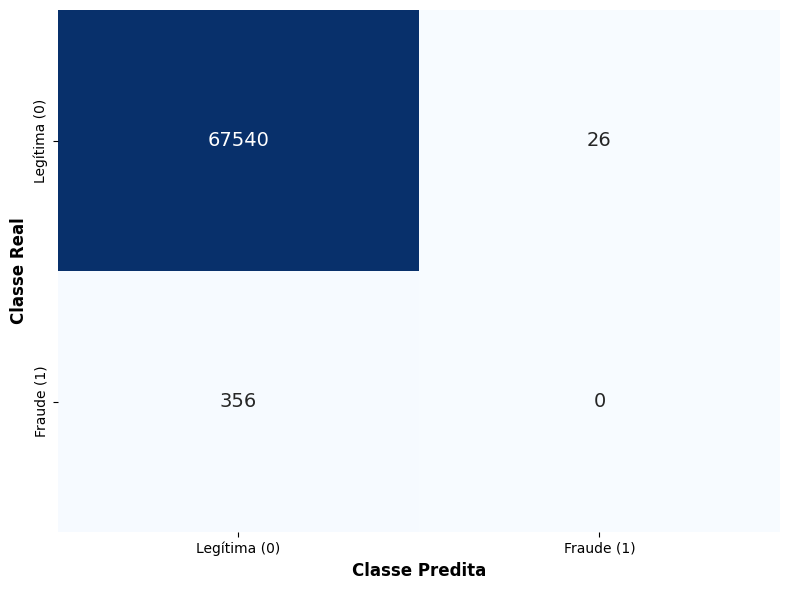

In [15]:
#PLOT
import matplotlib.pyplot as plt

# Opção 1: Usando os valores exatos que você extraiu (para testar o gráfico rápido)
cm = np.array([[67540, 26],
               [356, 0]])

# Opção 2: Quando for rodar de novo, basta apagar a matriz acima e descomentar a linha abaixo:
# cm = confusion_matrix(y_test, y_pred_log)

# Configurando o tamanho da figura
plt.figure(figsize=(8, 6))

# Criando o mapa de calor (heatmap)
# annot=True: coloca os números dentro dos quadrados
# fmt='d': garante que os números apareçam como inteiros e não em notação científica (ex: 6.7e+04)
# cmap='Blues': esquema de cores (você pode trocar para 'Reds' para dar um tom de "alerta")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legítima (0)', 'Fraude (1)'],
            yticklabels=['Legítima (0)', 'Fraude (1)'],
            annot_kws={"size": 14}) # Aumenta o tamanho da fonte dos números

# Adicionando rótulos e título para o seu relatório
plt.ylabel('Classe Real', fontsize=12, fontweight='bold')
plt.xlabel('Classe Predita', fontsize=12, fontweight='bold')

plt.savefig('matriz_confusao_baseline.pdf', dpi=300, bbox_inches='tight')

# Ajusta o layout para não cortar os textos e exibe o gráfico
plt.tight_layout()
plt.show()